Doğrusal ve doğrusal olmyana regresyon çeşitlerinde bağımlı değişkenlerimiz sürekliydi(sayısal), burada(sınıflandırma modellerinde) ise bağımlı değişkenlerimiz kategorik(metinsel) değişkenler olacak. Sınıflandırma modellerinin çıktısı sadece "metinsel" değil, aynı zamanda sayısal olarak ifade edilebilen kategoriler de olabilir. En önemli fark, regresyonun bir değer tahmin etmesi (örneğin 15.000 TL), sınıflandırmanın ise bir kategoriye atama yapmasıdır (örneğin "A Sınıfı" veya "B Sınıfı"). sınıflandırma kategorik olarak yapılacak yani.

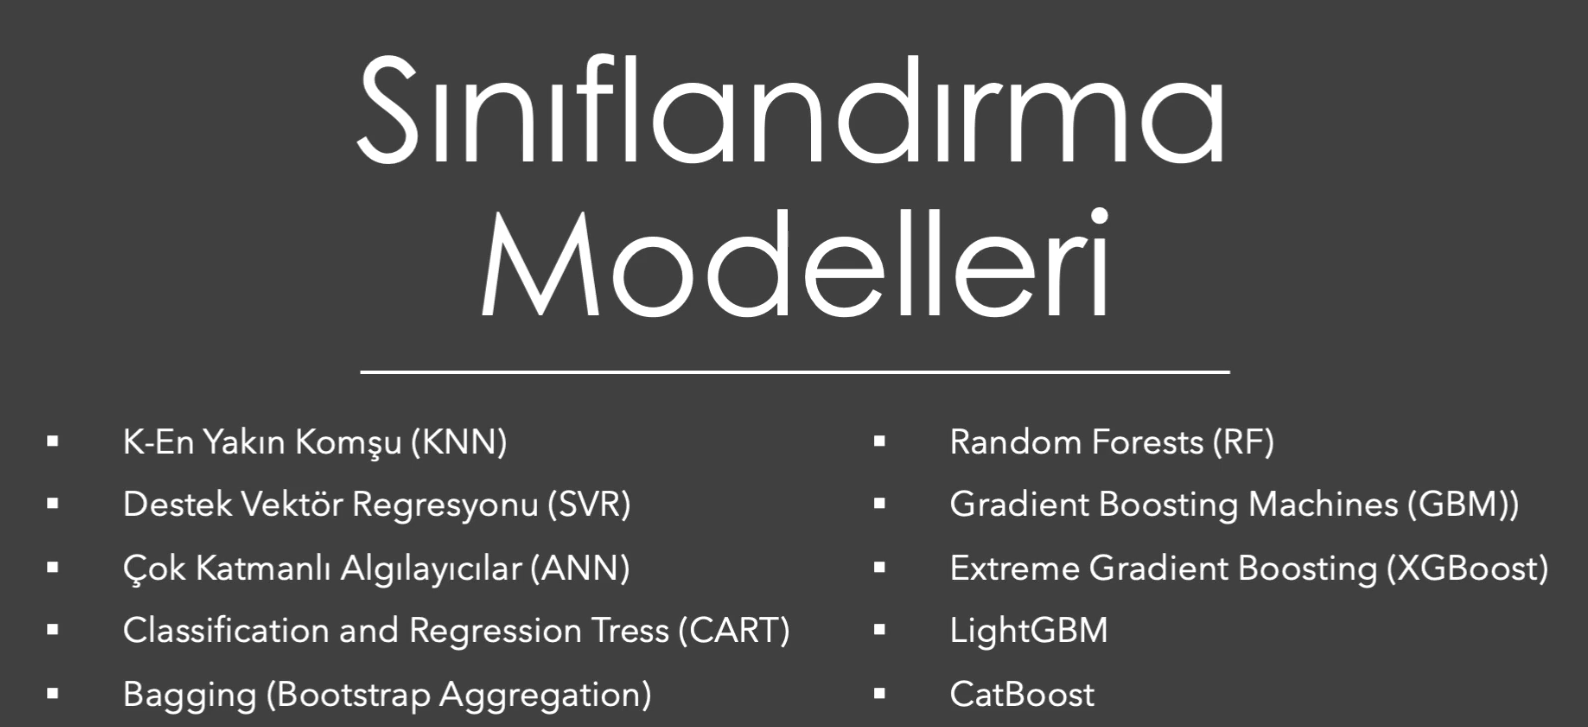

# Lojistik Regresyon

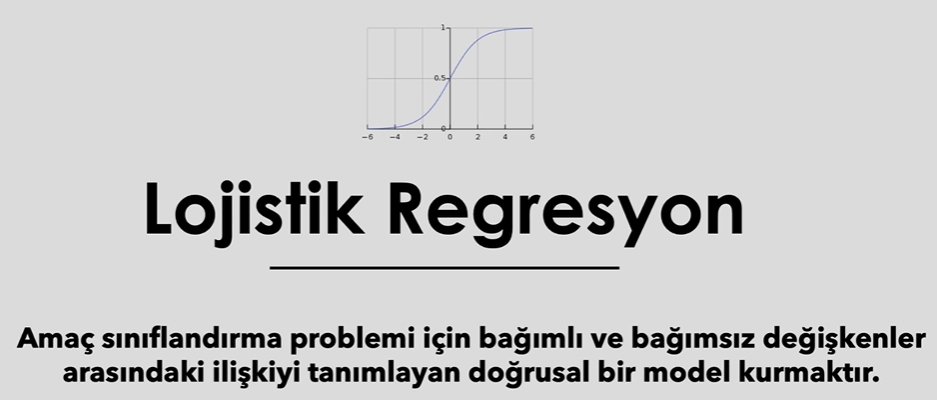

Burada aklımıza şu soru gelebilir: bu işi neden doğrusal regresyonla değil de lojistik regresyonlar yapıyoruz, doğrusal regresyonla yapamaz mıyız?

doğrusal regresyon kullanamayıp logistik regresyon kullanmamız gerektiği zamanlar:
* Bağımlı değişken 2'den fazla değer alacağı zamanlarda(0,1,2,3,4....)

Lojistik regresyonda grafikte de görebileceğimiz üzere bağımlı değişkenin 0 ile 1 arasında değerler alması garanti altına alınmış olunur.

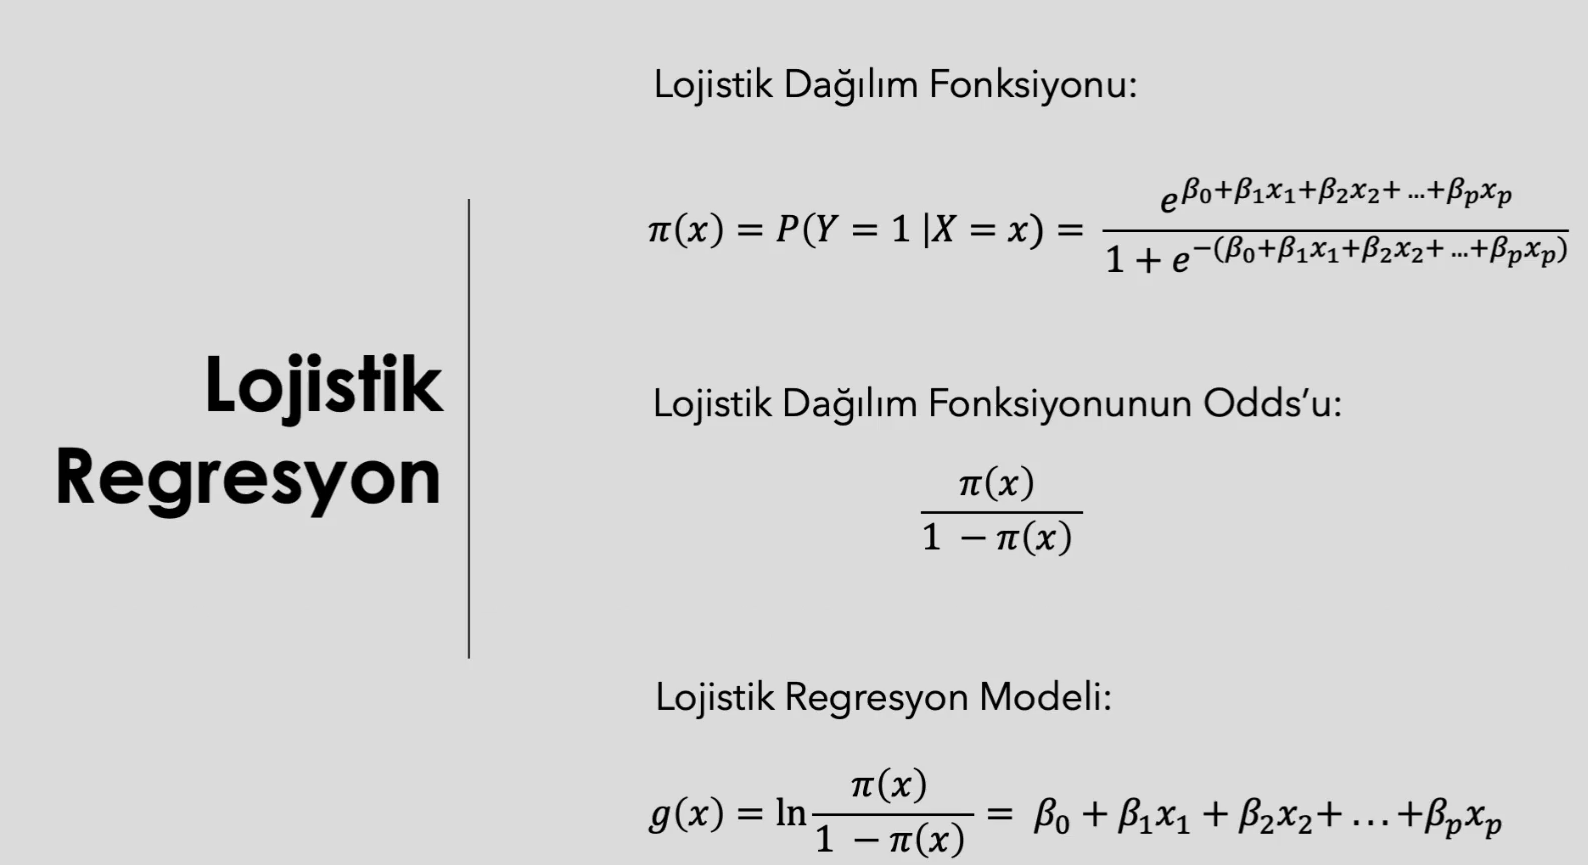

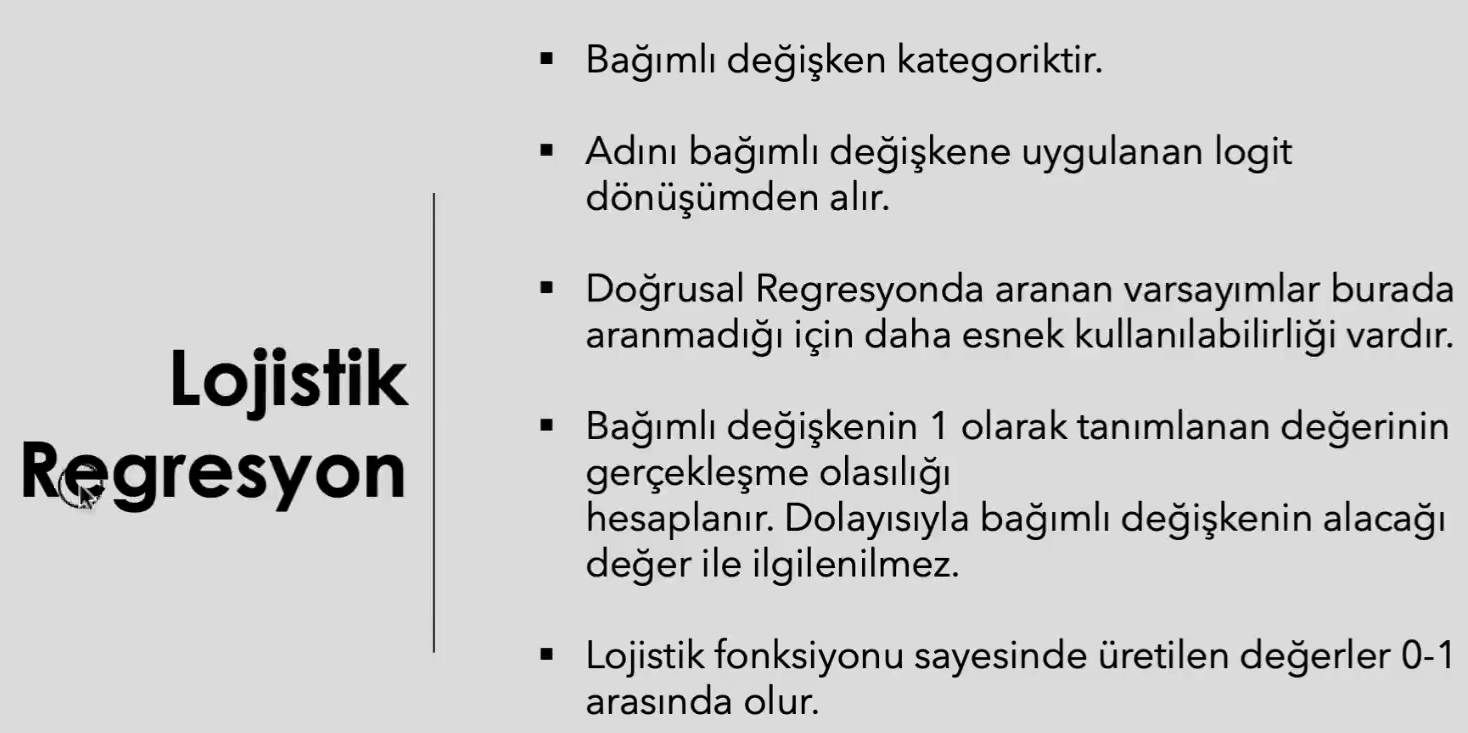

## Uygulama

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from warnings import filterwarnings
filterwarnings('ignore')

## Model

In [15]:
diabetes = pd.read_csv("diabetes.csv")
df = diabetes.copy()
df = df.dropna()
df.head()

# bu dataseti ile kuracağımız model, bir hasta geldiğinde onun şeker hastası olup olmadığını tahmin edecek.
# verisetini inceleyecek olursak: geçirdiği hamilelik sayısı, glikoz miktarı, kan basıncı, deri kalınlığı, insülin miktarı, BMI, yaş
# ve bunlara bağlı olarak şeker hastası olup olmadığını belirten outcome sütunu mevcut bu verisetinde

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [26]:
df["Outcome"].value_counts() # verisetimizde 500 adet şeker hastası olmayan, 268 adet şeker hastası olan kişilerin verileri varmış

Outcome
0    500
1    268
Name: count, dtype: int64

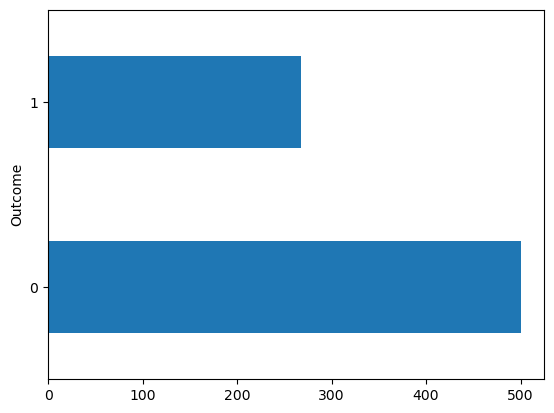

In [36]:
df["Outcome"].value_counts().plot.barh();

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [42]:
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1) # bağımlı ve bağımsız değişkenlerimizi belirledik

In [48]:
# statsmodels ile yapımı
loj = sm.Logit(y, X)
loj_model = loj.fit()

Optimization terminated successfully.
         Current function value: 0.608498
         Iterations 5


In [50]:
loj_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      760
Method:                           MLE   Df Model:                            7
Date:                Tue, 23 Sep 2025   Pseudo R-squ.:                 0.05922
Time:                        14:29:05   Log-Likelihood:                -467.33
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 2.583e-10
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Pregnancies                  0.1284      0.029      4.484      0.000       0.072       0.185
Glucose                      0.0129      0.003      4.757      0.000       0.008       0.018
BloodPressure               -0.0303      0.005     -6.481      0.000      -0.039      -0.021
SkinThickness                0.0002      0.006      0.032      0.974      -0.012       0.012
Insulin                      0.0007      0.001      0.942      0.346      -0.001       0.002
BMI                         -0.0048      0.011     -0.449      0.653      -0.026       0.016
DiabetesPedigreeFunction     0.3203      0.240      1.335      0.182      -0.150       0.790
Age                         -0.0156      0.008     -1.852      0.064      -0.032       0.001
============================================================================================
"""

In [57]:
# scikit-learn ile yapımı
from sklearn.linear_model import LogisticRegression

loj = LogisticRegression(solver="liblinear")
loj_model = loj.fit(X,y)

In [63]:
loj_model.intercept_ # bu modelin denklemininin sabit değeri

array([-5.88679617])

In [65]:
loj_model.coef_ # bu modelin katsayıları

array([[ 1.16994476e-01,  2.83733435e-02, -1.68981359e-02,
         7.55145090e-04, -6.41407258e-04,  5.97201268e-02,
         6.76128123e-01,  7.23498971e-03]])

## Tahmin & Model Tuning

In [80]:
# logistic regression'un diğer linear ya da nonlinear regressionlar gibi dışsal parametresi yok. tek parametresi sabit sayısı. 
# bu sebeple aslında tam anlamda bir tuning yapmayacağız, doğrulama yapmaya daha çok kayacak yaptıklarımız.
# doğrulama: sınıflandırma modellerinde, bağımlı değişkeni koyduğumuz sınıfı doğrulamamız gerekir. 
# şimdi confusion matrix ve accuracy değerlerine ulaşacağız

In [78]:
y_pred = loj_model.predict(X) # şu anlık test train ayrımı yapmadık, olmadığından değil uğraşmak istemediğimizden

In [84]:
confusion_matrix(y,y_pred) # confusion matrix bu şekilde

array([[448,  52],
       [121, 147]], dtype=int64)

In [88]:
accuracy_score(y,y_pred) # accuracy(model doğruluğu) bu şekilde

0.7747395833333334

In [92]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       500
           1       0.74      0.55      0.63       268

    accuracy                           0.77       768
   macro avg       0.76      0.72      0.73       768
weighted avg       0.77      0.77      0.77       768



### Doğru sınıfları doğru yere koyduk mu doğrulamasını yapma kısmı:

In [98]:
loj_model.predict(X)[0:10] # 0 ve 1 sonuçları ürettiği için sadece bunları görüyoruz, eğer olasılık olarak detaylı istersek:

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0], dtype=int64)

In [107]:
loj_model.predict_proba(X)[0:10] 
# bu şekilde oranları(probabilityleri) alabiliriz. bunun ilk sütunu sıfırların, ikinci sütunu birlerin olma olasılığını söyler

array([[0.3505852 , 0.6494148 ],
       [0.91692518, 0.08307482],
       [0.22489628, 0.77510372],
       [0.92127453, 0.07872547],
       [0.16759435, 0.83240565],
       [0.79886109, 0.20113891],
       [0.8800353 , 0.1199647 ],
       [0.27795677, 0.72204323],
       [0.32053464, 0.67946536],
       [0.92264521, 0.07735479]])

In [109]:
y[:10] # bunun ilk sütunu 0.index, 1.index, 2.index diye indexleri söylüyor. verisetimizle alakası yok

0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64

In [113]:
# özetle doğrulamayı nasıl yapıyoruz? 2 satır önceki loj_model.predict_proba(X)[0:10]'e bakıyoruz, 1.sütunda ilk outcome'ın sıfır olma olasılığı,
# 2.sütunda 1.outcome'ın 1 olma olasılığını söylüyor. yani diyor ki, 1.outcome değeri 0.3505852 olasılığıyla sıfır, 0.6494148 olasılığıyla birdir.
# gidiyorzu y[:10] değerinin ilk değerine bakıyoruz, 1, yani evet bu arkadaş doğru bilmiş. bu şekilde bir kaç değere bakıp doğru sınıflandırma
# yaptığımızı teyitliyoruz

In [133]:
# şimdi yazılımsal olarak aslında yukarıda loj_model.predict(X)[0:10] işlemini biz yapıcaz fakat loj_model.predict_proba(X)[0:10] çıktılarıyla...
# eğer 2.sütundaki değerler 0.5'den büyükse bunu 1 yap, değilse bunu 0 yap diyeceğiz.

my_array = np.array([])

second_column = loj_model.predict_proba(X)[:,1]

for i in second_column:
    if i>0.5:
        my_array = np.append(my_array, 1)
    else:
        my_array = np.append(my_array, 0)

print(my_array) # burada aldığımız çıktı loj_model.predict(X)[0:10] ile aynı olacak. o işlemi biz manuel yapmak istedik çünkü

[1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0.
 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0.
 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.

# Naive Bayes

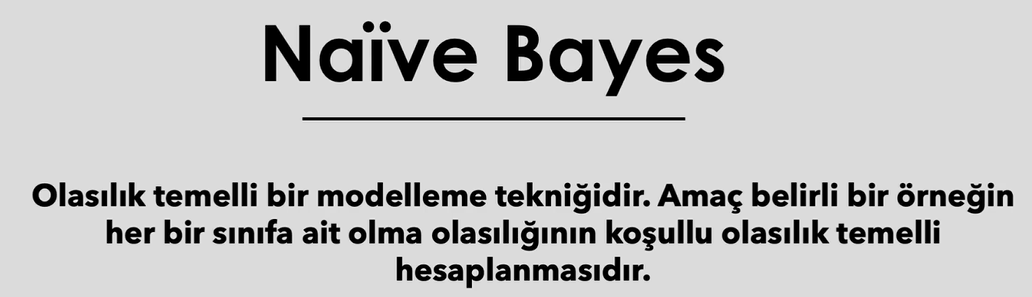

E-Ticaret gibi **çok kategorili** sınıf yapılarının olduğu senaryolarda modelleme yaparken bayes iyi çalışan bir modelleme tekniğidir.

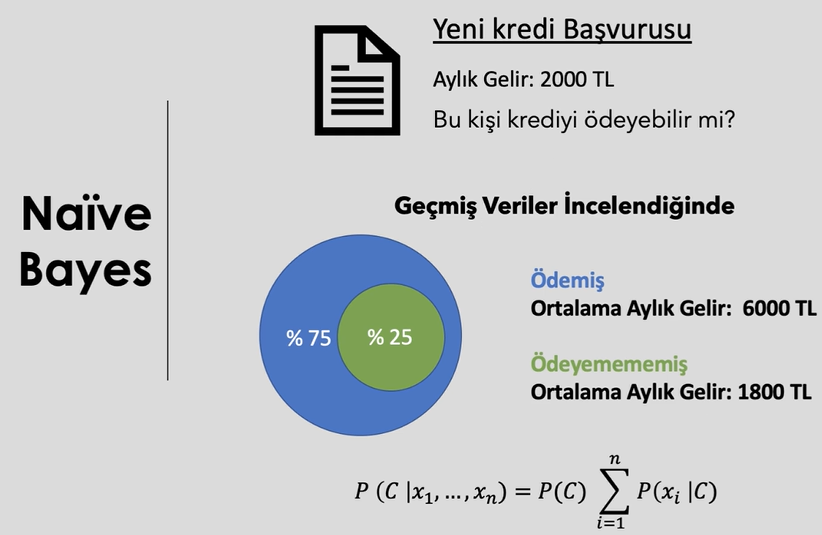

Naive Bayeste de, Lojistik Regresyonda olduğu gibi dışsal parametre yoktur, bu sebeple model tuning işlemi yapılamaz

## Gaussian Naive Bayes Uygulama

In [140]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [142]:
from sklearn.naive_bayes import GaussianNB

In [147]:
nb = GaussianNB()
nb_model = nb.fit(X_train, y_train)
nb_model

GaussianNB()

In [152]:
nb_model.predict(X_test)[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 1], dtype=int64)

In [156]:
nb_model.predict_proba(X_test)[:10]

array([[0.73815858, 0.26184142],
       [0.94027894, 0.05972106],
       [0.97242831, 0.02757169],
       [0.82840069, 0.17159931],
       [0.47153473, 0.52846527],
       [0.47274458, 0.52725542],
       [0.99607705, 0.00392295],
       [0.69925055, 0.30074945],
       [0.53838117, 0.46161883],
       [0.25004536, 0.74995464]])

In [158]:
y[:10]

0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64

In [160]:
y_pred = nb_model.predict(X_test)

In [162]:
accuracy_score(y_test, y_pred)

0.7445887445887446

In [168]:
cross_val_score(nb_model, X_test, y_test, cv=10).mean()

0.775

# KNN - K-Nearest Neighbors

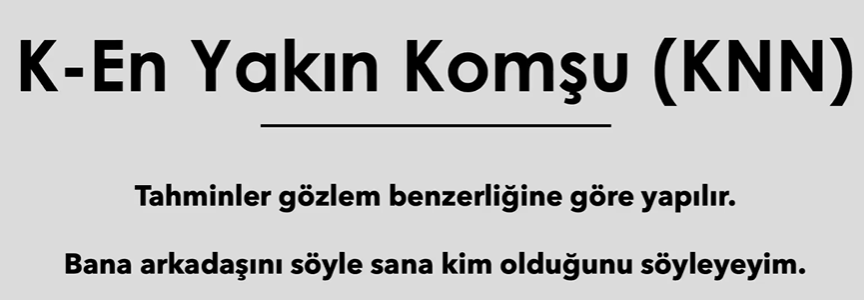

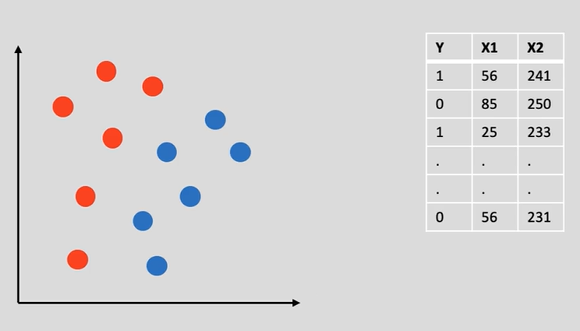

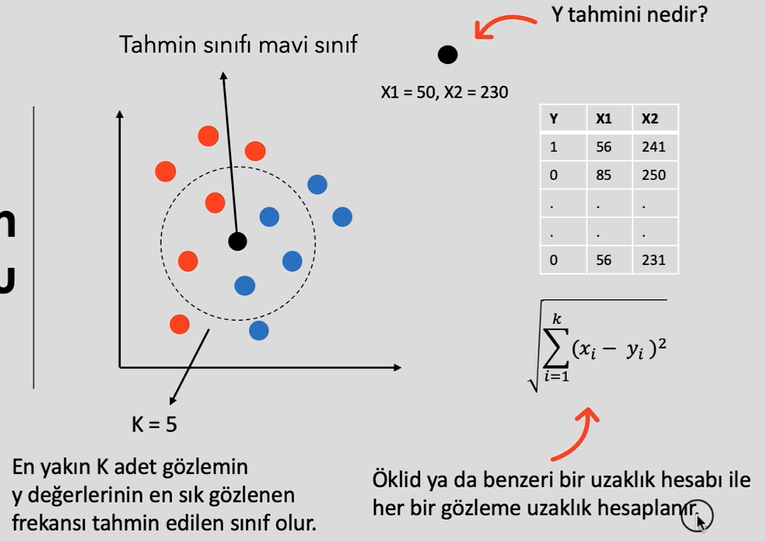

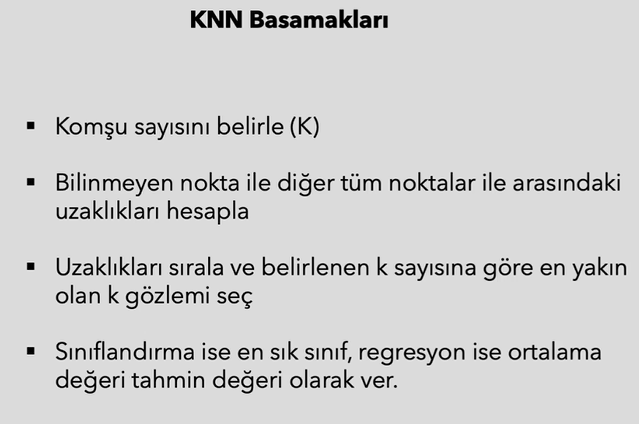

KNN'de dışsal hiperparametre vardır, bu da komşu sayısıdır.

## Model & Tahmin

In [178]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [182]:
knn = KNeighborsClassifier()
knn_model = knn.fit(X_train, y_train)
knn_model

KNeighborsClassifier()

In [184]:
y_pred = knn_model.predict(X_test)

In [188]:
accuracy_score(y_test, y_pred)

0.6883116883116883

In [190]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       151
           1       0.55      0.56      0.56        80

    accuracy                           0.69       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.69      0.69       231



## Model Tuning

In [193]:
knn_params = {'n_neighbors':np.arange(1,50)}

In [200]:
knn_cv_model = GridSearchCV(knn, knn_params, cv=10)
knn_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [204]:
print("En iyi skor KNN", knn_cv_model.best_score_)
print("En iyi parametreler", knn_cv_model.best_params_)

En iyi skor KNN 0.748637316561845
En iyi parametreler {'n_neighbors': 11}


## Final model kurma

In [207]:
knn = KNeighborsClassifier(11)
final_model = knn.fit(X_train, y_train)

In [211]:
y_pred = final_model.predict(X_test)

In [213]:
accuracy_score(y_test, y_pred)

0.7316017316017316

In [219]:
final_model.score(X_test, y_test) 

# bu, predicti de yapıp öyle skoru veriyor. y_pred=predict..... yapmak ve sonra accuracy score yapmak yerine bu da kullanılabilir. aynı şey

0.7316017316017316

# SVM - Support Vector Machine

Amaç: iki sınıf arasındaki ayrımın optimum olmasını sağlayacak hiper düzlemi bulmaktır.

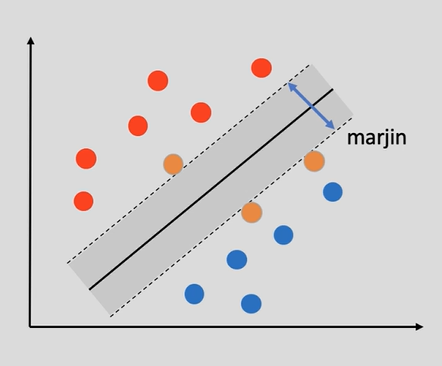

Amaç: iki sınıf arasındaki marjinin maksimum büyüklükte olmasını sağlamaktır. Bu da sınıflandırmanın daha net ve keskin yapılmasını sağlar ve iyi bir sınıflandırma yapmamızı sağlar.

Görüldüğü üzere bu doğru, hiçbir noktaya değmiyor, ve noktaları birbirinden ayırıyor. yani classification(sınıflandırma) yapıyor. En iyi svm, hiçbir noktaya değmeyendir.

Marjin, **marjine en yakın olan** noktadan diğer sınıftaki marjine en yakın noktaya olan mesafeye denir.

Gerçek hayatta bazı durumlarda veriler bu şekilde 2 boyutlu olmamaktadır, 3 boyutlu olduğunda bir doğru ile onları ayırmak mümkün olmamaktadır. Bu durumda ise kernel trick denilen bir yöntem kullanılarak resimdeki gibi düzeltmeler sağlanmaktadır:

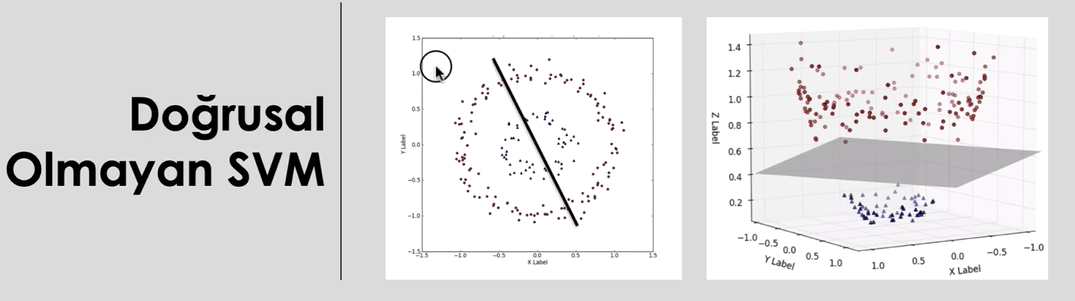

## Model & Tahmin

In [11]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [13]:
svm_model = SVC(kernel="linear").fit(X_train, y_train)

In [15]:
y_pred = svm_model.predict(X_test)

In [19]:
accuracy_score(y_test, y_pred)

0.7445887445887446

## Model Tuning

Regresyon bölümünde C hiperparametresi görmüştük. Bu hiperparametre, aykırı gözlemlerin göreceli olarak etkilerini kontrol altına almak için vardı, SVM'de de bu C hiperparametresi mevcut.

In [22]:
svm_params = {'C':np.arange(1,10)}

In [30]:
svm = SVC(kernel="linear")
svm_cv_model = GridSearchCV(svm, svm_params, cv=10, n_jobs=-1, verbose=2)
svm_cv_model.fit(X_train, y_train)
y_pred = svm_cv_model.predict(X_test)
accuracy_score(y_test, y_pred)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


KeyboardInterrupt: 

In [ ]:
svm_cv_model.best_params_

In [ ]:
svm_tuned = SVC(kernel = "linear", C=5)
svm_tuned.fit(X_train, y_train)
y_pred = svm_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

# RBF SVM (Linear Olmayan/Radial Bases Function SVM)

## Model & Tahmin

In [36]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [42]:
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)

SVC()

In [48]:
y_pred = svm_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7359307359307359

## Model Tuning

kernel=linearde yalnızca C hiperparametresi vardı, 3 boyutlu olan bu SVM RBF türünde C hiperparametresine ek olarak GAMA hiperparametresi de mevcut. onu da düzenliyor olacağız modelimizi iyileştirmek için.

In [57]:
svm_params = {'C':[0.0001, 0.001, 0.1, 1, 5, 10, 50, 100],
              'gamma':[0.0001, 0.001, 0.1, 1, 5, 10, 50, 100]}

In [61]:
svm = SVC(kernel="rbf")
svm_cv_model = GridSearchCV(svm, svm_params, cv=10)

In [63]:
svm_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.0001, 0.001, 0.1, 1, 5, 10, 50, 100],
                         'gamma': [0.0001, 0.001, 0.1, 1, 5, 10, 50, 100]})

In [65]:
svm_cv_model.best_params_

{'C': 10, 'gamma': 0.0001}

In [67]:
svm_tuned = SVC(kernel="rbf", C=10, gamma=0.0001)
svm_tuned.fit(X_train, y_train)
y_pred = svm_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.7359307359307359

# Yapay Sinir Ağları (Artificial Neural Networks)

Çok yönlü olan bu algoritmayı doğrusal olmayan regresyon konusunda da görmüştük. Orada tahmin yapıyordu, burada sınıflandırma yapıyor. 

In [16]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

In [20]:
# Yapay sinir ağları, değişkenlerin ölçeklerindne etkilendiği için önce bir standartlaştırma işlemi yapmamız gerekmekte. 
# Bu sebeple önce standartlaştırma yapacağız

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.neural_network import MLPClassifier # multi layer perceptron classifier demektir

In [40]:
mlp = MLPClassifier().fit(X_train_scaled, y_train)

In [41]:
mlp.coefs_

[array([[ 1.17410122e-01, -3.81978746e-01, -3.72457228e-02,
         -1.54694501e-01, -9.99940535e-02,  2.30703049e-02,
          4.70306130e-02, -3.56603359e-01, -1.22257024e-01,
         -2.90694338e-01, -2.40602637e-01, -2.25136968e-03,
          1.10679493e-01,  5.89139424e-02, -1.99896471e-01,
         -3.53883485e-01, -2.13742005e-01,  2.65040611e-01,
          9.40093268e-03,  5.81629863e-02,  8.58464387e-02,
          1.93592524e-01, -3.00487168e-01, -7.63772359e-02,
         -9.35371101e-02, -2.27734029e-01,  6.80969820e-02,
          1.46494749e-01, -1.09685540e-02, -1.51443507e-01,
          1.40704836e-01, -9.16938475e-02, -9.07940930e-02,
         -1.36441755e-01, -2.95105149e-02, -2.84006059e-01,
          4.75733912e-02, -9.05825703e-02, -2.20802726e-02,
          8.52729521e-02, -2.23314212e-01,  7.74977052e-02,
          1.97586558e-01,  8.42040590e-03, -1.96071934e-02,
          1.24168033e-01,  1.84628161e-01, -3.14972821e-02,
          8.05079806e-02,  1.46141125e-0

In [43]:
y_pred = mlp.predict(X_test_scaled)
accuracy_score(y_pred, y_test)

0.7402597402597403

## Model Tuning

Model algoritmaları karmaşıklaştıkça, algoritmanın karakteristiğini bilmek zorundayız. Örneğin yapay sinir ağını modellemek yukarıdaki gibi kolay ama aslında öyle değil. Ağ topolojisi ve optimizasyonu ile alakalı olarak yapay sinir ağının arkaplanında var olan:

* aktivasyon fonksiyonları
* ağırlıklar ve onun için gerekli solver argümanı
* Adam, gradyan, newton gibi metodlardan hangisinin kullanılacağı
* Katman sayısı

Konuları gibi konuları bilmek gerekir.

Örneğin yapay sinir ağında ön tanımlı gelen metot, Adam metodudur fakat şu anda spesifik olarak bizim örneğimizde buna gerek yok çünkü Adam metodu, çok büyük verisetlerinde kullanılan bir metot.

In [55]:
?mlp 
# burada yapay sinir ağının ne gibi parametreler alabileceği, ne gibi oynamalar yapabileceğimize bakabiliriz

Type:        MLPClassifier
String form: MLPClassifier()
File:        c:\users\since\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py
Docstring:  
Multi-layer Perceptron classifier.

This model optimizes the log-loss function using LBFGS or stochastic
gradient descent.

.. versionadded:: 0.18

Parameters
----------
hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
    The ith element represents the number of neurons in the ith
    hidden layer.

activation : {'identity', 'logistic', 'tanh', 'relu'}, default='relu'
    Activation function for the hidden layer.

    - 'identity', no-op activation, useful to implement linear bottleneck,
      returns f(x) = x

    - 'logistic', the logistic sigmoid function,
      returns f(x) = 1 / (1 + exp(-x)).

    - 'tanh', the hyperbolic tan function,
      returns f(x) = tanh(x).

    - 'relu', the rectified linear unit function,
      returns f(x) = max(0, x)

solver : {'lbfgs', 'sgd', 'adam'}, defa

In [59]:
mlp_params = {
    "alpha": [0.1, 0.01, 0.02, 0.005, 0.0001, 0.00001], # ceza parametresi
    "hidden_layer_sizes": [                             # gizli katmanların sayıları 
        (10, 10, 10),
        (100, 100, 100),
        (100, 100),
        (3, 5),
        (5, 3)
    ],
    "solver": ["lbfgs", "adam", "sgd"],                 # metotlar
    "activation": ["relu", "logistic"]                  # aktivasyon fonksiyonu olan ve ön tanımlı olan relu ve sigmoid fonksiyonlarını denicez
}

In [61]:
mlp = MLPClassifier()
mlp_cv_model = GridSearchCV(mlp, mlp_params, cv=10)
mlp_cv_model.fit(X_train_scaled, y_train)
y_pred = mlp_cv_model.predict(X_test_scaled)
accuracy_score(y_pred, y_test)

0.7662337662337663

In [63]:
mlp_cv_model.best_params_ # bu parametreleri kullanarak tekrardan modelimizi oluşturacağız

{'activation': 'relu',
 'alpha': 0.1,
 'hidden_layer_sizes': (100, 100),
 'solver': 'sgd'}

In [71]:
mlp_tuned = MLPClassifier(activation = "logistic",
                           alpha = 0.1,
                           hidden_layer_sizes = (100, 100, 100),
                           solver = "adam")

In [72]:
mlp_tuned.fit(X_train_scaled, y_train)

MLPClassifier(activation='logistic', alpha=0.1,
              hidden_layer_sizes=(100, 100, 100))

In [73]:
y_pred = mlp_tuned.predict(X_test_scaled)

In [74]:
accuracy_score(y_pred, y_test)

0.7359307359307359

# CART - Classification and Regression Trees

Adı üzerinde zaten, aynı artificial neural networksdeki gibi hem classification hem de regression konularında kullanılır.

Amaç: Verisetindeki karmaşık yapıları basit karar ağaçlarına(decision trees) dönüştürmektir. 

Heterojen verisetleri belirlenmiş bir hedef değişkene göre homojen alt gruplara ayrılır.

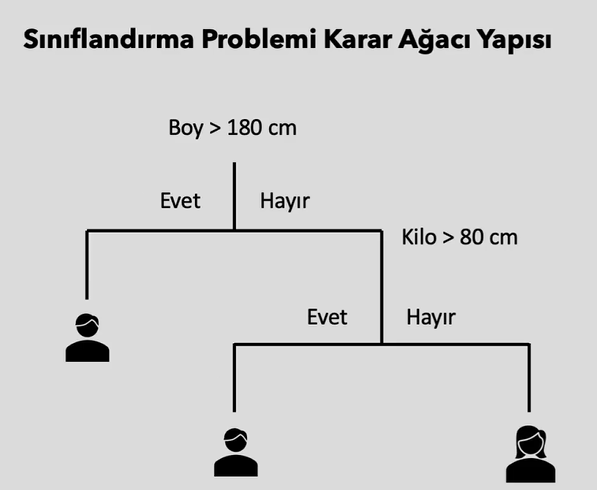

Hayır oldukça sağa, evet oldukça sola(tam tersi de olabilir, bize bağlı.) elemanlar eklenen basit bir ağaç yapısına çeviriyor herşeyi. 

## Model & Tahmin

In [112]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [114]:
from sklearn.tree import DecisionTreeClassifier

In [116]:
cart = DecisionTreeClassifier()
cart_model = cart.fit(X_train, y_train)
cart_model

DecisionTreeClassifier()

In [118]:
!pip install skompiler
from skompiler import skompile

In [119]:
# bu yukarıdaki resimde de gözükebileceği üzere, boy 180cm'den fazla ise sola, değilse sağa tarzı gidişatta 
# birinin bu karar kurallarını belirlemesi gerkeiyor. şimdi bunu yapıcaz:

In [120]:
print(skompile(cart_model.predict).to("python/code"))

((((((0 if x[6] <= 0.671999990940094 else 1 if x[6] <= 0.6974999904632568 else
    0) if x[5] <= 31.40000057220459 else ((0 if x[3] <= 40.5 else 1) if x[1
    ] <= 111.5 else ((0 if x[5] <= 32.59999942779541 else 1) if x[2] <= 
    65.0 else 0) if x[2] <= 72.0 else 1) if x[4] <= 9.0 else (0 if x[6] <= 
    0.6395000219345093 else 1 if x[6] <= 0.6759999990463257 else 0) if x[0] <=
    4.5 else 0 if x[6] <= 0.39149999618530273 else 1) if x[5] <= 
    49.10000038146973 else 1) if x[1] <= 127.5 else 1 if x[2] <= 56.0 else 
    (0 if x[7] <= 27.5 else 1 if x[5] <= 28.149999618530273 else 0) if x[5] <=
    30.300000190734863 else 1 if x[5] <= 32.000000953674316 else ((0 if x[5
    ] <= 33.75 else 1) if x[0] <= 0.5 else 1 if x[5] <= 32.45000076293945 else
    0) if x[2] <= 85.0 else 1) if x[7] <= 28.5 else (1 if x[7] <= 29.5 else
    (1 if x[1] <= 130.5 else 0) if x[5] <= 9.649999618530273 else 0 if x[1] <=
    133.0 else (0 if x[2] <= 66.5 else 1) if x[2] <= 73.0 else 0) if x[5] <=
    26.94

In [127]:
y_pred = cart_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7186147186147186

## Model Tuning

In [132]:
cart_params = {
    "max_depth": list(range(1,10)),
    "min_samples_split": list(range(2,50)),
}

In [134]:
cart = DecisionTreeClassifier()
cart_cv = GridSearchCV(cart, cart_params, cv=10)
cart_cv_model = cart_cv.fit(X_train, y_train)

In [135]:
cart_cv_model.best_params_

{'max_depth': 5, 'min_samples_split': 19}

In [144]:
cart = DecisionTreeClassifier(max_depth = 5, min_samples_split = 19)
cart_tuned = cart_cv.fit(X_train, y_train)

In [146]:
y_pred = cart_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.7532467532467533

# Random Forests Classification (Rastgele Ormanlar)

Bir çok decision treenin ürettiği tahminlerin bir arada değerlendirilerek ortaya çıkarılan tahmin yöntemidir.

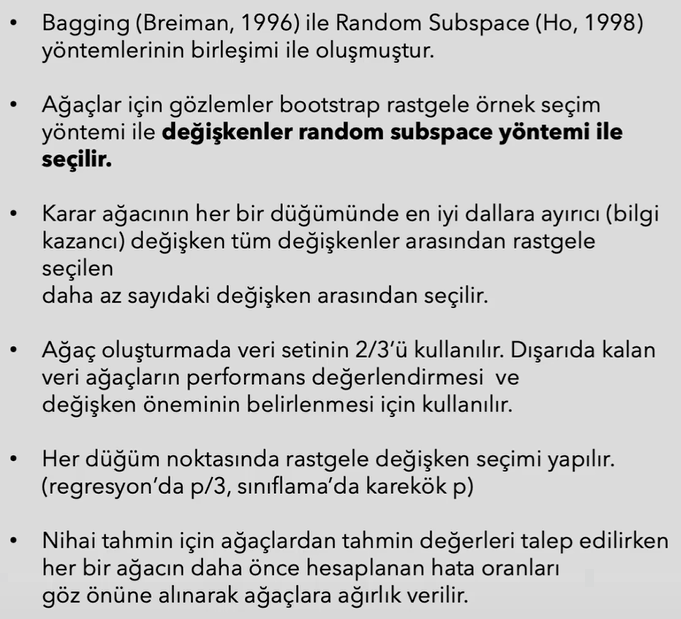

## Model & Tahmin

In [285]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [287]:
from sklearn.ensemble import RandomForestClassifier

In [291]:
rf = RandomForestClassifier()
rf_model = rf.fit(X_train, y_train)

In [293]:
y_pred = rf_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7402597402597403

## Model Tuning

Random foresten 2 adet önemli hiperparametresi var. bunlardan 1.si: kullanılacak olan ağaç sayısı, 2.si: bölünmelerde göz önünde bulundurulacak değişken sayısı. Ayrıyeten random forest ve begging, parametre değişiminde en fazla senaryo üreten algoritmalardır. Çünkü 10 katlı cross validation yapacağımızı düşünürsek her bir ağaçta 10 katlı cross validationdan makinayı yakarsın herhalde. Binlerce farklı ihtimal otaya çıkıyor.

In [298]:
rf_params = {
    "max_depth":[2,5,8,10],
    "max_features":[2,5,8],
    "n_estimators":[10, 500, 1000],
    "min_samples_split":[2, 5, 10]
}

In [ ]:
rf = RandomForestClassifier()
rf_cv_model = GridSearchCV(rf, rf_params, cv=10)
rf_cv_model.fit(X_train, y_train)

In [ ]:
rf_cv_model.best_params_

In [ ]:
final_model = RandomForestClassifier(max_depth=10, max_features=8, min_samples_split=10, n_estimators=1000).fit(X_train, y_train)
y_pred = final_model.predict(X_test)
accuracy_score(y_test, y_pred)

In [ ]:
Importance = pd.DataFrame({"Importance": final_model.feature_importances_ * 100},
                           index = X_train.columns)

Importance.sort_values(by = "Importance",
                       axis = 0,
                       ascending = True).plot(kind = "barh", color = "r")

plt.xlabel("Değişken Önem Düzeyleri")

# verisetimiz içerisindeki hangi sütunun, bağımlı değişkenimiz için daha fazla öneme sahip olduğunu gösteriyoruz burada. bence çok önemli

# GBM - Gradient Boosting Machines

AdaBoostun sınıflandırma ve regresyon problemlerine kolayca uyarlanabilen genelleştirilmiş versiyonudur. Artıklar üzerinde tek bir tahminsel model formunda olan modeller serisi kurulur. Zayıf öğrencilerin bir araya gelerek güçlü bir öğrenci ortaya çıkartması fikrine dayanıyor.

AdaBoost(Adaptive Boosting): Zayıf sınıflandırıcıların bir araya gelerek güçlü bir sınıflandırıcı oluşturması fikrini hayata geçiren algoritmadır.

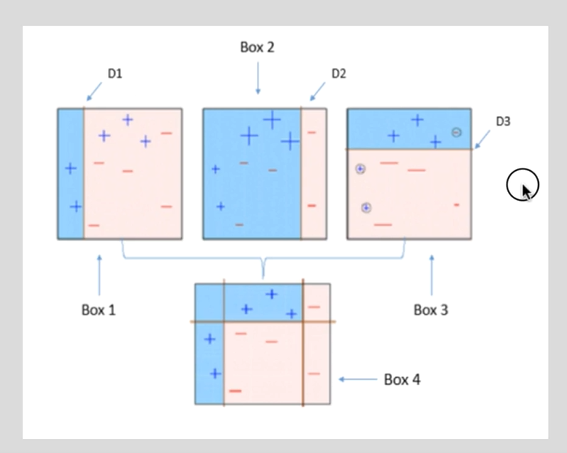

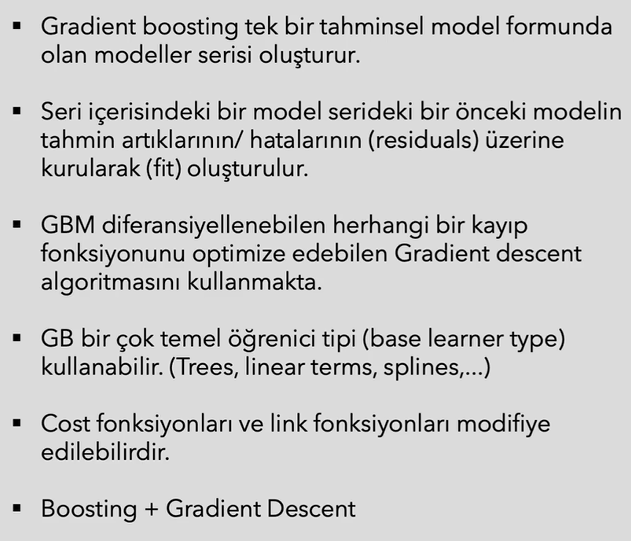

Bagging ve boostingler birbirlerine karıştırılır her ikisi de decision treelere dayandığı için. şimdi onların ayrımlarını yapalım:

* Bagging: Birbirinden *bağımsız* ağaçlar oluşturur. Bu bağımsızlık sayesinde rassallık sağlanmıştır.
* Boosting: Tek bir tahminsel model formunda olan modeller serisi oluşturulur, bu modeller de birbirine *bağımlıdır*

## Model & Tahmin

In [18]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

In [26]:
gbm = GradientBoostingClassifier()
gbm_model = gbm.fit(X_train, y_train)

In [30]:
y_pred = gbm_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7489177489177489

## Model Tuning

In [33]:
gbm_model

GradientBoostingClassifier()

In [41]:
?gbm_model

# burada gbm modeli için kullanılabilecek parametrelere bakıyoruz

Type:        GradientBoostingClassifier
String form: GradientBoostingClassifier()
Length:      100
File:        c:\users\since\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py
Docstring:  
Gradient Boosting for classification.

This algorithm builds an additive model in a forward stage-wise fashion; it
allows for the optimization of arbitrary differentiable loss functions. In
each stage ``n_classes_`` regression trees are fit on the negative gradient
of the loss function, e.g. binary or multiclass log loss. Binary
classification is a special case where only a single regression tree is
induced.

:class:`sklearn.ensemble.HistGradientBoostingClassifier` is a much faster
variant of this algorithm for intermediate datasets (`n_samples >= 10_000`).

Read more in the :ref:`User Guide <gradient_boosting>`.

Parameters
----------
loss : {'log_loss', 'deviance', 'exponential'}, default='log_loss'
    The loss function to be optimized. 'log_loss' refers to binomial and
    multinomial deviance

In [43]:
gbm_params = {
    "learning_rate": [0.001, 0.01, 0.1, 0.05],
    "n_estimators": [100, 500, 1000],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

In [45]:
gbm = GradientBoostingClassifier()
gbm_cv_model = GridSearchCV(gbm, gbm_params, cv=10, n_jobs=-1, verbose=2)
gbm_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


GridSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 0.05],
                         'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 500, 1000]},
             verbose=2)

In [46]:
gbm_cv_model.best_params_

{'learning_rate': 0.05,
 'max_depth': 5,
 'min_samples_split': 10,
 'n_estimators': 100}

In [98]:
gbm = GradientBoostingClassifier(learning_rate=0.02, max_depth=6, min_samples_split=15, n_estimators=100)
tuned_gbm = gbm.fit(X_train, y_train)

In [99]:
y_pred = tuned_gbm.predict(X_test)
accuracy_score(y_test, y_pred)

0.7575757575757576

# XGBoost - eXtreme Gradient Boosting

XGBoost, GBM'in hız ve tahmin performansını artırmak üzere optimize edilmiş, ölçeklenebilir ve farklı platformlara entegre edilebilir halidir.

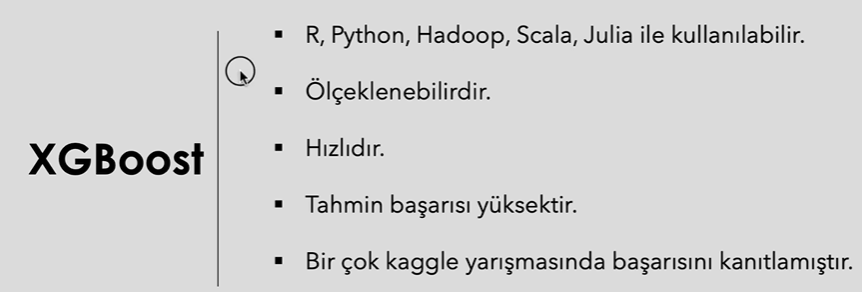

## Model & Prediction

In [102]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [106]:
from xgboost import XGBClassifier

In [108]:
xgb = XGBClassifier()
xgb_model = xgb.fit(X_train, y_train)

In [110]:
y_pred = xgb_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7142857142857143

## Model Tuning

In [116]:
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [118]:
?xgb_model

Type:        XGBClassifier
String form:
XGBClassifier(base_score=None, booster=None, callbacks=None,
           colsample_bylevel=None <...> , multi_strategy=None, n_estimators=None,
           n_jobs=None, num_parallel_tree=None, ...)
File:        c:\users\since\anaconda3\lib\site-packages\xgboost\sklearn.py
Docstring:  
Implementation of the scikit-learn API for XGBoost classification.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : Optional[int]
        Number of boosting rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: 

In [138]:
xgb_params = {
    'n_estimators': [100, 500, 1000, 2000],
    'subsample': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.02, 0.05],
    "min_samples_split": [2, 5, 10]
}

In [140]:
xgb = XGBClassifier()
xgb_cv_model = GridSearchCV(xgb, xgb_params, cv = 10, n_jobs = -1, verbose = 2)

In [142]:
xgb_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 576 candidates, totalling 5760 fits


KeyboardInterrupt: 

In [143]:
xgb_cv_model.best_params_

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [145]:
xgb = XGBClassifier(learning_rate = 0.01,
                    max_depth = 6,
                    min_samples_split = 2,
                    n_estimators = 100,
                    subsample = 0.8)

xgb_tuned = xgb.fit(X_train,y_train)

In [147]:
y_pred = xgb_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.7619047619047619

# Light GBM

XGBoost'un eğitim süresi perforansını artırmaya yönelik geliştirilen bir diğer GBM türüdür.

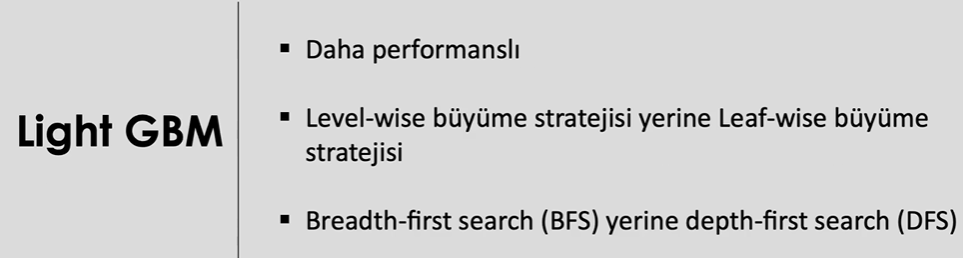

## Model & Prediction

In [155]:
df = diabetes.copy()
df = df.dropna()
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [157]:
from lightgbm import LGBMClassifier

In [159]:
lgbm = LGBMClassifier()
lgbm_model = lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 188, number of negative: 349
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350093 -> initscore=-0.618630
[LightGBM] [Info] Start training from score -0.618630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [163]:
y_pred = lgbm_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7229437229437229

## Model Tuning

In [168]:
lgbm_model

LGBMClassifier()

In [170]:
?lgbm_model

Type:           LGBMClassifier
String form:    LGBMClassifier()
File:           c:\users\since\anaconda3\lib\site-packages\lightgbm\sklearn.py
Docstring:      LightGBM classifier.
Init docstring:
Construct a gradient boosting model.

Parameters
----------
boosting_type : str, optional (default='gbdt')
    'gbdt', traditional Gradient Boosting Decision Tree.
    'dart', Dropouts meet Multiple Additive Regression Trees.
    'rf', Random Forest.
num_leaves : int, optional (default=31)
    Maximum tree leaves for base learners.
max_depth : int, optional (default=-1)
    Maximum tree depth for base learners, <=0 means no limit.
    If setting this to a positive value, consider also changing ``num_leaves`` to ``<= 2^max_depth``.
learning_rate : float, optional (default=0.1)
    Boosting learning rate.
    You can use ``callbacks`` parameter of ``fit`` method to shrink/adapt learning rate
    in training using ``reset_parameter`` callback.
    Note, that this will ignore the ``learning_rate``

In [172]:
lgbm_params = {
    'n_estimators': [100, 500, 1000, 2000],
    'subsample': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.02, 0.05],
    "min_child_samples": [5, 10, 20]
}

In [174]:
lgbm = LGBMClassifier()

lgbm_cv_model = GridSearchCV(lgbm, lgbm_params, 
                             cv = 10,
                             n_jobs = -1, 
                             verbose = 2)

In [176]:
lgbm_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 576 candidates, totalling 5760 fits


KeyboardInterrupt: 

In [178]:
y_pred = lgbm_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

NameError: name 'lgbm_tuned' is not defined